# Final Project - Phân loại cảm xúc bình luận Tiki bằng TF-IDF + SVM

Notebook này là bản hoàn chỉnh hơn cho dữ liệu `merged_dataset.csv` gồm 3 cột chính:

- `comment`: nội dung bình luận
- `label`: nhãn cảm xúc `POS`, `NEU`, `NEG`
- `rate`: số sao từ 1 đến 5

Notebook thực hiện đầy đủ quy trình:

1. Đọc và kiểm tra dữ liệu.
2. Kiểm tra lỗi dữ liệu, trùng lặp, thiếu dữ liệu, sai nhãn.
3. Chuẩn hóa nhãn theo rating sao.
4. Tiền xử lý tiếng Việt: chữ thường, chuẩn hóa viết tắt, emoji, ký tự lặp, phủ định.
5. Lọc bình luận rác / quá ít thông tin.
6. Phân tích phân bố dữ liệu.
7. Huấn luyện mô hình phân loại `POS / NEU / NEG`.
8. Huấn luyện mô hình dự đoán rating `1-5 sao`.
9. Đánh giá bằng Accuracy, Macro F1, Classification Report, Confusion Matrix.
10. Tạo hàm chatbot trả lời tự động.
11. Tạo hàm phân tích hàng loạt bình luận.
12. Lưu model để triển khai app.
13. Có thêm phần crawler Tiki mẫu để lấy bình luận từ link sản phẩm.

## 0. Cài thư viện cần thiết

Chạy cell dưới nếu máy bạn chưa có thư viện. Nếu đã cài rồi, có thể bỏ qua.

In [2]:
# Nếu thiếu thư viện, bỏ dấu # ở dòng dưới rồi chạy
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib requests beautifulsoup4 lxml tqdm

## 1. Import thư viện và cấu hình

In [3]:
import os
import re
import json
import html
import time
import math
import random
import unicodedata
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42
DATA_PATH = 'merged_dataset.csv'
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

LABEL_ORDER = ['NEG', 'NEU', 'POS']
RATING_ORDER = [1, 2, 3, 4, 5]

## 2. Đọc dữ liệu

In [4]:
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f'Không tìm thấy file {DATA_PATH}. Hãy đặt file CSV cùng thư mục với notebook.')

df_raw = pd.read_csv(DATA_PATH)
print('Kích thước dữ liệu gốc:', df_raw.shape)
df_raw.head()

Kích thước dữ liệu gốc: (39246, 3)


,comment,label,rate
0,Áo bao đẹp ạ!!,POS,5
1,Tuyệt vời !,POS,5
2,2day ao khong giong trong.,NEG,1
3,"Mùi thơm,bôi lên da mềm da.",POS,5
4,"Vải đẹp, dày dặn.",POS,5


## 3. Kiểm tra nhanh chất lượng dữ liệu

In [5]:
def quick_report(df: pd.DataFrame, name='Data'):
    print(f'===== {name} =====')
    print('Shape:', df.shape)
    print('\nColumns:', list(df.columns))
    print('\nDtypes:')
    print(df.dtypes)
    print('\nMissing values:')
    print(df.isna().sum())
    if 'label' in df.columns:
        print('\nLabel distribution:')
        print(df['label'].value_counts(dropna=False))
    if 'rate' in df.columns:
        print('\nRating distribution:')
        print(df['rate'].value_counts(dropna=False).sort_index())
    if 'comment' in df.columns:
        print('\nDuplicated comments:', df['comment'].duplicated().sum())

quick_report(df_raw, 'Raw data')

===== Raw data =====
Shape: (39246, 3)

Columns: ['comment', 'label', 'rate']

Dtypes:
comment      str
label        str
rate       int64
dtype: object

Missing values:
comment    0
label      0
rate       0
dtype: int64

Label distribution:
label
POS    25029
NEG     8507
NEU     5710
Name: count, dtype: int64

Rating distribution:
rate
1     4800
2     3707
3     5710
4     8073
5    16956
Name: count, dtype: int64

Duplicated comments: 4658


## 4. Chuẩn hóa cấu trúc dữ liệu

Ở bước này ta đảm bảo dữ liệu có đúng 3 cột cần dùng: `comment`, `label`, `rate`.

In [6]:
required_cols = {'comment', 'label', 'rate'}
missing_cols = required_cols - set(df_raw.columns)
if missing_cols:
    raise ValueError(f'Thiếu cột bắt buộc: {missing_cols}')

df = df_raw[['comment', 'label', 'rate']].copy()

df['comment'] = df['comment'].astype(str)
df['label'] = df['label'].astype(str).str.upper().str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Xóa dòng thiếu dữ liệu cơ bản
df = df.dropna(subset=['comment', 'label', 'rate']).copy()
df['rate'] = df['rate'].astype(int)

# Chỉ giữ rating hợp lệ 1-5 và label hợp lệ
df = df[df['rate'].between(1, 5)].copy()
df = df[df['label'].isin(['POS', 'NEU', 'NEG'])].copy()

print('Sau chuẩn hóa cấu trúc:', df.shape)
df.head()

Sau chuẩn hóa cấu trúc: (39246, 3)


,comment,label,rate
0,Áo bao đẹp ạ!!,POS,5
1,Tuyệt vời !,POS,5
2,2day ao khong giong trong.,NEG,1
3,"Mùi thơm,bôi lên da mềm da.",POS,5
4,"Vải đẹp, dày dặn.",POS,5


## 5. Kiểm tra và sửa sai lệch giữa `rate` và `label`

Với dữ liệu review Tiki, rating sao thường đáng tin hơn nhãn tự gán. Ta quy đổi:

- 1, 2 sao → `NEG`
- 3 sao → `NEU`
- 4, 5 sao → `POS`

Nếu `label` gốc khác với nhãn suy ra từ `rate`, notebook sẽ dùng nhãn từ `rate` làm `label_final`.

In [7]:
def label_from_rate(rate: int) -> str:
    if rate <= 2:
        return 'NEG'
    if rate == 3:
        return 'NEU'
    return 'POS'

df['label_from_rate'] = df['rate'].apply(label_from_rate)
df['label_mismatch'] = df['label'] != df['label_from_rate']

print('Số dòng label khác với rating:', df['label_mismatch'].sum())
print('Tỷ lệ sai lệch:', round(df['label_mismatch'].mean() * 100, 2), '%')

if df['label_mismatch'].sum() > 0:
    display(df[df['label_mismatch']].head(10))

# Dùng nhãn chuẩn theo rating để nhất quán hơn
df['label_final'] = df['label_from_rate']

Số dòng label khác với rating: 0
Tỷ lệ sai lệch: 0.0 %


## 6. Hàm tiền xử lý tiếng Việt

Hàm này xử lý các vấn đề thường gặp trong bình luận thật:

- HTML, URL, email, số điện thoại.
- Emoji tích cực / tiêu cực.
- Viết tắt: `ko`, `k`, `khong`, `sp`, `dc`, `mn`, ...
- Ký tự lặp: `đẹppppp` → `đẹpp`.
- Phủ định: `không tốt` → `không_tốt` để TF-IDF hiểu cụm phủ định.
- Xóa ký tự không cần thiết nhưng vẫn giữ tiếng Việt.

In [8]:
# Một số từ viết tắt phổ biến trong review sản phẩm
SLANG_MAP = {
    r'\bko\b': 'không',
    r'\bk\b': 'không',
    r'\bkhong\b': 'không',
    r'\bhok\b': 'không',
    r'\bhong\b': 'không',
    r'\bkg\b': 'không',
    r'\bkh\b': 'không',
    r'\bđc\b': 'được',
    r'\bdc\b': 'được',
    r'\bok\b': 'ổn',
    r'\boke\b': 'ổn',
    r'\boki\b': 'ổn',
    r'\bsp\b': 'sản phẩm',
    r'\bspham\b': 'sản phẩm',
    r'\bsx\b': 'sản xuất',
    r'\bhdsd\b': 'hướng dẫn sử dụng',
    r'\bmn\b': 'mọi người',
    r'\bmk\b': 'mình',
    r'\bmik\b': 'mình',
    r'\bvs\b': 'với',
    r'\bwa\b': 'quá',
    r'\bqa\b': 'quá',
    r'\bqá\b': 'quá',
    r'\bdep\b': 'đẹp',
    r'\btot\b': 'tốt',
    r'\bxau\b': 'xấu',
    r'\bnhanhh\b': 'nhanh',
    r'\bship\b': 'giao hàng',
}

POS_EMOJI_RE = re.compile('[😀😃😄😁😆😊🙂😍🥰😘👍❤♥️✨⭐🌟]')
NEG_EMOJI_RE = re.compile('[😞😔😟😢😭😡😠👎💔]')

NEGATIONS = {'không', 'chưa', 'chẳng', 'chả', 'ko', 'k', 'khong', 'hok', 'hong'}
PUNCT_RE = re.compile(r'[^0-9a-zA-ZÀ-ỹ_\s]')
MULTISPACE_RE = re.compile(r'\s+')
REPEAT_CHAR_RE = re.compile(r'(.)\1{2,}')
URL_RE = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\S+@\S+')
PHONE_RE = re.compile(r'\b\d{9,11}\b')


def normalize_unicode(text: str) -> str:
    return unicodedata.normalize('NFC', str(text))


def normalize_slang(text: str) -> str:
    for pattern, repl in SLANG_MAP.items():
        text = re.sub(pattern, repl, text)
    return text


def join_negation(text: str) -> str:
    """Ghép từ phủ định với 1 từ ngay sau nó: không tốt -> không_tốt."""
    tokens = text.split()
    new_tokens = []
    i = 0
    while i < len(tokens):
        if tokens[i] in NEGATIONS and i + 1 < len(tokens):
            new_tokens.append(tokens[i] + '_' + tokens[i + 1])
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1
    return ' '.join(new_tokens)


def clean_comment(text: str) -> str:
    text = normalize_unicode(text)
    text = html.unescape(text)
    text = text.lower().strip()
    
    # Emoji -> token cảm xúc
    text = POS_EMOJI_RE.sub(' positive_emoji ', text)
    text = NEG_EMOJI_RE.sub(' negative_emoji ', text)
    
    # Xóa thông tin không cần thiết
    text = URL_RE.sub(' ', text)
    text = EMAIL_RE.sub(' ', text)
    text = PHONE_RE.sub(' ', text)
    
    # Giảm ký tự lặp quá nhiều: đẹpppp -> đẹpp
    text = REPEAT_CHAR_RE.sub(r'\1\1', text)
    
    # Chuẩn hóa viết tắt trước khi xóa ký tự
    text = normalize_slang(text)
    
    # Giữ chữ, số, tiếng Việt, dấu gạch dưới; bỏ ký tự còn lại
    text = PUNCT_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    
    # Chuẩn hóa viết tắt lần 2 sau khi đã tách dấu câu
    text = normalize_slang(text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    
    # Ghép phủ định
    text = join_negation(text)
    return text

# Test nhanh
examples = [
    'Shop giao hàng nhanh, sp đẹp lắmmmm!!! ♥',
    '2day ao khong giong trong.',
    'ko tốt, hàng lỗi :(',
    'OK nha mn, đóng gói kĩ',
]
for e in examples:
    print(e, '=>', clean_comment(e))

Shop giao hàng nhanh, sp đẹp lắmmmm!!! ♥ => shop giao hàng nhanh sản phẩm đẹp lắmm positive_emoji
2day ao khong giong trong. => 2day ao không_giong trong
ko tốt, hàng lỗi :( => không_tốt hàng lỗi
OK nha mn, đóng gói kĩ => ổn nha mọi người đóng gói kĩ


## 7. Áp dụng tiền xử lý và lọc nhiễu

In [9]:
df['clean_text'] = df['comment'].apply(clean_comment)
df['num_words'] = df['clean_text'].str.split().apply(len)
df['num_chars'] = df['clean_text'].str.len()

# Từ khóa một từ vẫn có thông tin, không nên xóa hết các câu ngắn như "tốt", "đẹp", "tệ".
INFORMATIVE_SINGLE_WORDS = {
    'tốt', 'đẹp', 'xấu', 'tệ', 'ổn', 'ok', 'được', 'thích', 'ưng', 'chán', 'lỗi',
    'positive_emoji', 'negative_emoji'
}

def is_low_information(text: str) -> bool:
    tokens = text.split()
    if len(tokens) == 0:
        return True
    if len(tokens) == 1 and tokens[0] not in INFORMATIVE_SINGLE_WORDS:
        return True
    # Xóa chuỗi chỉ toàn số
    if re.fullmatch(r'[0-9\s]+', text):
        return True
    return False

before = len(df)
df = df[~df['clean_text'].apply(is_low_information)].copy()
print('Xóa dòng ít thông tin:', before - len(df))

# Xóa trùng lặp theo text đã làm sạch + rating để tránh bias do comment lặp
before = len(df)
df = df.drop_duplicates(subset=['clean_text', 'rate']).copy()
print('Xóa dòng trùng lặp:', before - len(df))

print('Dữ liệu sau tiền xử lý:', df.shape)
df[['comment', 'clean_text', 'label_final', 'rate']].head(10)

Xóa dòng ít thông tin: 272
Xóa dòng trùng lặp: 5066
Dữ liệu sau tiền xử lý: (33908, 9)


,comment,clean_text,label_final,rate
0,Áo bao đẹp ạ!!,áo bao đẹp ạ,POS,5
1,Tuyệt vời !,tuyệt vời,POS,5
2,2day ao khong giong trong.,2day ao không_giong trong,NEG,1
3,"Mùi thơm,bôi lên da mềm da.",mùi thơm bôi lên da mềm da,POS,5
4,"Vải đẹp, dày dặn.",vải đẹp dày dặn,POS,5
5,"Hàng rất đẹp, rất chi là ưng ý.",hàng rất đẹp rất chi là ưng ý,POS,5
6,"Chất lượng sản phẩm tốt, date dài.",chất lượng sản phẩm tốt date dài,POS,5
7,Ăn nói và thái độ phục vụ tốt.,ăn nói và thái độ phục vụ tốt,POS,4
8,Đóng gói sản phẩm chắc chắn.,đóng gói sản phẩm chắc chắn,POS,5
9,tất sờn hết ca chưa dùng mà vay r.,tất sờn hết ca chưa_dùng mà vay r,NEG,2


## 8. Phân tích phân bố dữ liệu sau xử lý

Phân bố label_final:
label_final
POS    20580
NEG     8071
NEU     5257
Name: count, dtype: int64

Phân bố rating:
rate
1     4493
2     3578
3     5257
4     6879
5    13701
Name: count, dtype: int64


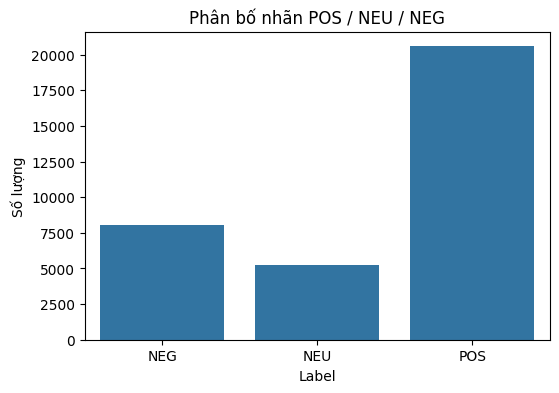

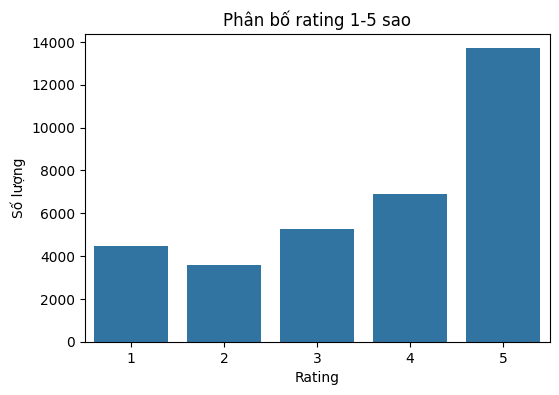

In [10]:
print('Phân bố label_final:')
print(df['label_final'].value_counts())
print('\nPhân bố rating:')
print(df['rate'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label_final', order=LABEL_ORDER)
plt.title('Phân bố nhãn POS / NEU / NEG')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='rate', order=RATING_ORDER)
plt.title('Phân bố rating 1-5 sao')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.show()

## 9. Chia train/test

Dùng stratify để tập train/test giữ tỷ lệ lớp tương đối giống nhau.

In [11]:
X = df['clean_text']
y_label = df['label_final']
y_rate = df['rate']

X_train, X_test, y_label_train, y_label_test, y_rate_train, y_rate_test = train_test_split(
    X,
    y_label,
    y_rate,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_label,
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)
print('\nTrain label distribution:')
print(y_label_train.value_counts(normalize=True).round(3))
print('\nTest label distribution:')
print(y_label_test.value_counts(normalize=True).round(3))

Train: (27126,)
Test: (6782,)

Train label distribution:
label_final
POS    0.607
NEG    0.238
NEU    0.155
Name: proportion, dtype: float64

Test label distribution:
label_final
POS    0.607
NEG    0.238
NEU    0.155
Name: proportion, dtype: float64


## 10. Hàm huấn luyện và đánh giá model

Dùng pipeline:

`TF-IDF ngram 1-3` → `LinearSVC class_weight='balanced'`

`class_weight='balanced'` giúp model bớt thiên vị lớp POS khi dữ liệu mất cân bằng.

In [12]:
def build_pipeline():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 3),
            max_features=80000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents=None,
        )),
        ('clf', LinearSVC(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            max_iter=5000,
        ))
    ])


def train_with_grid_search(X_train, y_train, task_name='label'):
    pipeline = build_pipeline()
    param_grid = {
        'clf__C': [0.3, 0.7, 1.0, 2.0],
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )
    grid.fit(X_train, y_train)
    print(f'Best params for {task_name}:', grid.best_params_)
    print(f'Best CV Macro F1 for {task_name}:', round(grid.best_score_, 4))
    return grid.best_estimator_, grid


def evaluate_model(model, X_test, y_test, labels, title='Model'):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f'===== {title} =====')
    print('Accuracy:', round(acc, 4))
    print('Macro F1:', round(macro_f1, 4))
    print('Weighted F1:', round(weighted_f1, 4))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, labels=labels, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(title + ' - Confusion Matrix')
    plt.show()
    
    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'y_pred': y_pred,
        'confusion_matrix': cm,
    }

## 11. Huấn luyện model phân loại cảm xúc POS / NEU / NEG

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params for POS_NEU_NEG: {'clf__C': 0.3}
Best CV Macro F1 for POS_NEU_NEG: 0.6417
===== Sentiment POS / NEU / NEG =====
Accuracy: 0.7706
Macro F1: 0.6532
Weighted F1: 0.7631

Classification Report:
              precision    recall  f1-score   support

         NEG       0.70      0.78      0.74      1614
         NEU       0.39      0.30      0.34      1052
         POS       0.88      0.89      0.88      4116

    accuracy                           0.77      6782
   macro avg       0.65      0.66      0.65      6782
weighted avg       0.76      0.77      0.76      6782



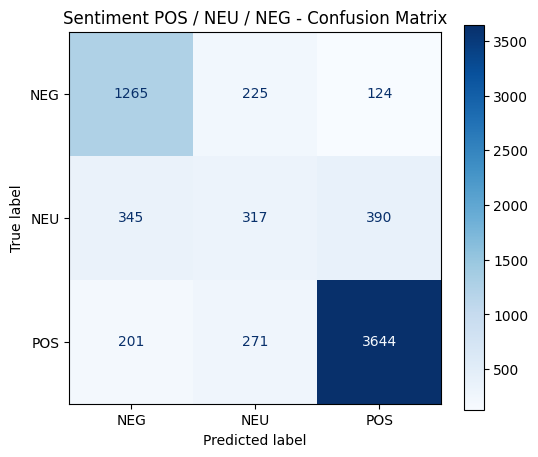

In [13]:
label_model, label_grid = train_with_grid_search(X_train, y_label_train, task_name='POS_NEU_NEG')
label_metrics = evaluate_model(
    label_model,
    X_test,
    y_label_test,
    labels=LABEL_ORDER,
    title='Sentiment POS / NEU / NEG'
)

## 12. Huấn luyện model dự đoán rating 1-5 sao

Model 1-5 sao khó hơn vì các lớp gần nhau dễ bị nhầm, ví dụ 4 sao và 5 sao. Nhưng phần này giúp báo cáo đúng yêu cầu đề tài 5 cấp độ.

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params for rating_1_5: {'clf__C': 0.3}
Best CV Macro F1 for rating_1_5: 0.4565
===== Rating 1-5 sao =====
Accuracy: 0.5404
Macro F1: 0.4566
Weighted F1: 0.5269

Classification Report:
              precision    recall  f1-score   support

           1       0.53      0.65      0.58       899
           2       0.31      0.32      0.32       716
           3       0.34      0.32      0.33      1051
           4       0.37      0.25      0.30      1376
           5       0.72      0.79      0.75      2740

    accuracy                           0.54      6782
   macro avg       0.45      0.47      0.46      6782
weighted avg       0.52      0.54      0.53      6782



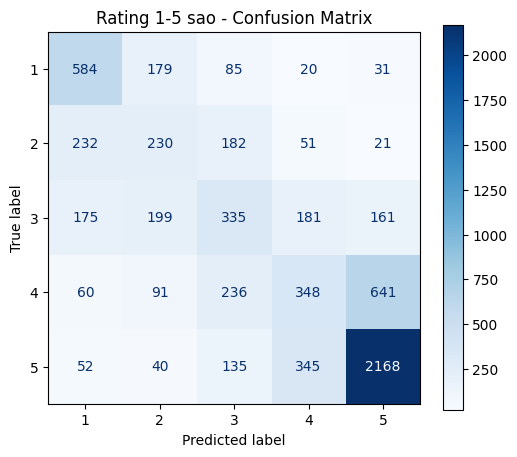

In [14]:
# Với rating, stratify tốt hơn theo rate để giữ đủ 5 lớp
X_train_r, X_test_r, y_rate_train_r, y_rate_test_r = train_test_split(
    df['clean_text'],
    df['rate'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['rate'],
)

rating_model, rating_grid = train_with_grid_search(X_train_r, y_rate_train_r, task_name='rating_1_5')
rating_metrics = evaluate_model(
    rating_model,
    X_test_r,
    y_rate_test_r,
    labels=RATING_ORDER,
    title='Rating 1-5 sao'
)

## 13. Phân tích lỗi dự đoán

Xem các mẫu model dự đoán sai để biết cần bổ sung tiền xử lý hoặc dữ liệu nào.

In [15]:
y_label_pred = label_model.predict(X_test)
error_df = pd.DataFrame({
    'text': X_test.values,
    'true_label': y_label_test.values,
    'pred_label': y_label_pred,
})
error_df = error_df[error_df['true_label'] != error_df['pred_label']]
print('Số mẫu sai:', len(error_df))
display(error_df.sample(min(15, len(error_df)), random_state=RANDOM_STATE))

Số mẫu sai: 1556


,text,true_label,pred_label
6533,mua ngày 19_2 cảm nhận bàn phím không_nhạy mới cả cảm biến nữa để qua đêm mất 4 pin pin khoẻ tiếc là không_có ốp lưn...,NEU,POS
692,bé xíu,NEG,NEU
1484,đánh giá sau 1 tháng xử dụng loa ngoài nhỏ màn hình khi gọi video đôi khi bị lỗi nháy ngang màn hình đã đổi trả khi ...,NEU,NEG
1983,nhưng thời gian giao hàng hơi lâu,POS,NEG
6198,thời gian giao hàng rất nhanh trong hộp không_thấy phiếu bảo hành không_biết mai mốt nếu có trục trặc thì sao,NEU,POS
6557,túi có quai xách rất ổn nhưng mỏng quá,POS,NEU
240,em mới vào game chỉnh phần turbo trên góc thì kêu è è mãi em khởi động lại thì nó hết rồi,POS,NEU
1743,đt này chơi game thì khá ngon á nhưng mà bắt wifi quá yếu camera rất xấu lunn chụp hình như sác chết á nên anh em câ...,NEG,POS
3094,pin trâu dùng mượt sóng wifi thì hơi yếu trừ 1 sao vì camera xấu tệ xấu hơn cả joy1,POS,NEG
1493,nhưng với số tiền ý thì cũng không_dám mong đợi gì quá nhiều,NEU,NEG


## 14. Hàm dự đoán một bình luận mới

Hàm này tự làm sạch text rồi đưa vào model.

In [16]:
RATING_NAME = {
    1: 'Rất không hài lòng',
    2: 'Không hài lòng',
    3: 'Trung tính',
    4: 'Hài lòng',
    5: 'Rất hài lòng',
}

LABEL_NAME = {
    'NEG': 'Tiêu cực',
    'NEU': 'Trung tính',
    'POS': 'Tích cực',
}


def margin_confidence(model, texts):
    """Ước lượng độ tin cậy bằng khoảng cách decision_function.
    Không phải xác suất thật, nhưng đủ để cảnh báo mẫu không chắc chắn.
    """
    scores = model.decision_function(texts)
    scores = np.asarray(scores)
    if scores.ndim == 1:
        return np.abs(scores)
    sorted_scores = np.sort(scores, axis=1)
    return sorted_scores[:, -1] - sorted_scores[:, -2]


def predict_comment(comment: str, show=True):
    clean = clean_comment(comment)
    label = label_model.predict([clean])[0]
    rate = int(rating_model.predict([clean])[0])
    conf = float(margin_confidence(label_model, [clean])[0])
    result = {
        'original_text': comment,
        'clean_text': clean,
        'label': label,
        'label_name': LABEL_NAME[label],
        'rating': rate,
        'rating_name': RATING_NAME[rate],
        'confidence_margin': round(conf, 4),
    }
    if show:
        print('Bình luận gốc:', result['original_text'])
        print('Sau xử lý:', result['clean_text'])
        print('Cảm xúc:', result['label'], '-', result['label_name'])
        print('Rating dự đoán:', result['rating'], '-', result['rating_name'])
        print('Độ chắc chắn tương đối:', result['confidence_margin'])
    return result

predict_comment('Sản phẩm đẹp, giao hàng nhanh, đóng gói cẩn thận')
predict_comment('Hàng quá tệ, mới dùng đã hỏng, rất thất vọng')
predict_comment('Sản phẩm bình thường, dùng tạm được')

Bình luận gốc: Sản phẩm đẹp, giao hàng nhanh, đóng gói cẩn thận
Sau xử lý: sản phẩm đẹp giao hàng nhanh đóng gói cẩn thận
Cảm xúc: POS - Tích cực
Rating dự đoán: 5 - Rất hài lòng
Độ chắc chắn tương đối: 1.9469
Bình luận gốc: Hàng quá tệ, mới dùng đã hỏng, rất thất vọng
Sau xử lý: hàng quá tệ mới dùng đã hỏng rất thất vọng
Cảm xúc: NEG - Tiêu cực
Rating dự đoán: 1 - Rất không hài lòng
Độ chắc chắn tương đối: 2.3211
Bình luận gốc: Sản phẩm bình thường, dùng tạm được
Sau xử lý: sản phẩm bình thường dùng tạm được
Cảm xúc: NEU - Trung tính
Rating dự đoán: 3 - Trung tính
Độ chắc chắn tương đối: 2.093


{'original_text': 'Sản phẩm bình thường, dùng tạm được',
 'clean_text': 'sản phẩm bình thường dùng tạm được',
 'label': 'NEU',
 'label_name': 'Trung tính',
 'rating': 3,
 'rating_name': 'Trung tính',
 'confidence_margin': 2.093}

## 15. Chatbot trả lời tự động theo cảm xúc và từ khóa

Phần này biến model thành chatbot rule-based đơn giản nhưng phù hợp đề tài.

In [17]:
RESPONSE_TEMPLATES = {
    'POS': [
        'Cảm ơn bạn rất nhiều vì đã tin tưởng và ủng hộ shop! Shop rất vui khi bạn hài lòng với sản phẩm.',
        'Shop cảm ơn đánh giá tích cực của bạn. Hy vọng sẽ tiếp tục được phục vụ bạn trong những lần mua sau.',
        'Cảm ơn bạn đã phản hồi. Sự hài lòng của bạn là động lực để shop tiếp tục cải thiện chất lượng dịch vụ.',
    ],
    'NEU': [
        'Cảm ơn bạn đã dành thời gian phản hồi. Shop ghi nhận góp ý của bạn và sẽ cố gắng cải thiện hơn.',
        'Shop cảm ơn đánh giá trung thực của bạn. Nếu cần hỗ trợ thêm, bạn có thể nhắn trực tiếp cho shop.',
        'Cảm ơn bạn đã góp ý. Shop sẽ tiếp tục cải thiện sản phẩm và dịch vụ để mang lại trải nghiệm tốt hơn.',
    ],
    'NEG': [
        'Shop thành thật xin lỗi vì trải nghiệm chưa tốt của bạn. Bạn vui lòng liên hệ shop để được hỗ trợ xử lý sớm nhất.',
        'Rất xin lỗi bạn về vấn đề gặp phải. Shop ghi nhận phản hồi và sẽ kiểm tra lại để hỗ trợ bạn tốt hơn.',
        'Shop xin lỗi vì sản phẩm/dịch vụ chưa đáp ứng kỳ vọng. Bạn vui lòng nhắn tin cho shop để được hỗ trợ đổi trả hoặc bảo hành nếu phù hợp.',
    ]
}

KEYWORD_RESPONSES = {
    'giao': ' Shop sẽ kiểm tra thêm với đơn vị vận chuyển để cải thiện tốc độ giao hàng.',
    'ship': ' Shop sẽ kiểm tra thêm với đơn vị vận chuyển để cải thiện tốc độ giao hàng.',
    'đóng gói': ' Shop sẽ lưu ý kỹ hơn khâu đóng gói để sản phẩm đến tay khách hàng an toàn hơn.',
    'lỗi': ' Shop sẽ kiểm tra lại tình trạng lỗi và hỗ trợ bạn theo chính sách đổi trả/bảo hành.',
    'hỏng': ' Shop sẽ kiểm tra lại tình trạng hỏng và hỗ trợ bạn theo chính sách đổi trả/bảo hành.',
    'size': ' Shop sẽ bổ sung hướng dẫn chọn size rõ ràng hơn để khách dễ lựa chọn.',
    'màu': ' Shop sẽ cố gắng cập nhật hình ảnh/màu sắc sản phẩm sát thực tế hơn.',
    'chất lượng': ' Shop luôn ghi nhận phản hồi về chất lượng để cải thiện sản phẩm tốt hơn.',
}


def generate_reply(comment: str):
    pred = predict_comment(comment, show=False)
    label = pred['label']
    reply = random.choice(RESPONSE_TEMPLATES[label])
    clean = pred['clean_text']
    
    for kw, extra in KEYWORD_RESPONSES.items():
        if kw in clean:
            reply += extra
            break
    
    # Cảnh báo nếu model không chắc chắn
    if pred['confidence_margin'] < 0.2:
        reply += ' Lưu ý: bình luận này có sắc thái chưa rõ, nên có thể cần nhân viên kiểm tra thêm.'
    
    return {
        **pred,
        'reply': reply,
    }

result = generate_reply('Hàng giao hơi chậm nhưng sản phẩm dùng cũng ổn')
result

{'original_text': 'Hàng giao hơi chậm nhưng sản phẩm dùng cũng ổn',
 'clean_text': 'hàng giao hơi chậm nhưng sản phẩm dùng cũng ổn',
 'label': 'POS',
 'label_name': 'Tích cực',
 'rating': 4,
 'rating_name': 'Hài lòng',
 'confidence_margin': 0.9402,
 'reply': 'Shop cảm ơn đánh giá tích cực của bạn. Hy vọng sẽ tiếp tục được phục vụ bạn trong những lần mua sau. Shop sẽ kiểm tra thêm với đơn vị vận chuyển để cải thiện tốc độ giao hàng.'}

## 16. Phân tích nhiều bình luận cùng lúc

Tổng số bình luận: 5
Điểm hài lòng trung bình dự đoán: 2.8 / 5

Phân phối cảm xúc:


,count,percent
label,,
NEG,2,40.0
NEU,0,0.0
POS,3,60.0


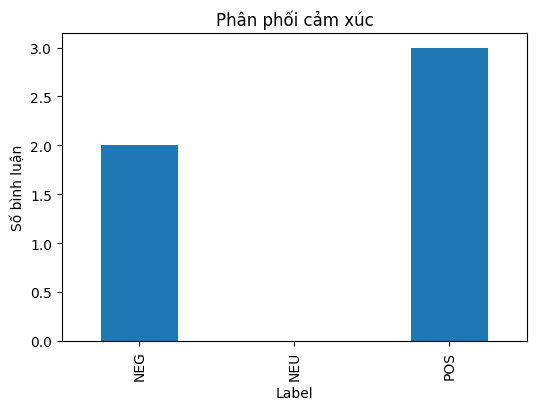

,original_text,label,rating,label_name
0,"Sản phẩm đẹp, giao hàng nhanh",POS,5,Tích cực
1,"Hàng lỗi, dùng một ngày đã hỏng",NEG,1,Tiêu cực
2,"Cũng bình thường, không quá tốt",POS,3,Tích cực
3,"Đóng gói cẩn thận, chất lượng ổn",POS,4,Tích cực
4,"Shop giao sai màu, rất thất vọng",NEG,1,Tiêu cực


In [18]:
def analyze_comments(comments):
    rows = []
    for c in comments:
        rows.append(predict_comment(c, show=False))
    result_df = pd.DataFrame(rows)
    
    total = len(result_df)
    label_counts = result_df['label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
    label_percent = (label_counts / total * 100).round(2)
    avg_rating = result_df['rating'].mean().round(2)
    
    print('Tổng số bình luận:', total)
    print('Điểm hài lòng trung bình dự đoán:', avg_rating, '/ 5')
    print('\nPhân phối cảm xúc:')
    summary = pd.DataFrame({'count': label_counts, 'percent': label_percent})
    display(summary)
    
    plt.figure(figsize=(6, 4))
    summary['count'].plot(kind='bar')
    plt.title('Phân phối cảm xúc')
    plt.xlabel('Label')
    plt.ylabel('Số bình luận')
    plt.show()
    
    return result_df, summary

sample_comments = [
    'Sản phẩm đẹp, giao hàng nhanh',
    'Hàng lỗi, dùng một ngày đã hỏng',
    'Cũng bình thường, không quá tốt',
    'Đóng gói cẩn thận, chất lượng ổn',
    'Shop giao sai màu, rất thất vọng',
]

analysis_df, analysis_summary = analyze_comments(sample_comments)
analysis_df[['original_text', 'label', 'rating', 'reply' if 'reply' in analysis_df.columns else 'label_name']].head()

## 17. Trích xuất từ khóa tích cực / tiêu cực

Phần này giúp làm báo cáo phân tích sản phẩm: khách thích gì và phàn nàn gì.

In [19]:
STOPWORDS = {
    'và', 'là', 'của', 'cho', 'với', 'rất', 'quá', 'thì', 'mà', 'này', 'nọ', 'đó', 'ạ', 'nhé',
    'shop', 'sản', 'phẩm', 'sản_phẩm', 'mình', 'bạn', 'hàng', 'được', 'có', 'không', 'không_được'
}


def top_keywords(texts, top_n=15):
    counter = Counter()
    for text in texts:
        for tok in str(text).split():
            if len(tok) >= 2 and tok not in STOPWORDS and not tok.isdigit():
                counter[tok] += 1
    return pd.DataFrame(counter.most_common(top_n), columns=['keyword', 'count'])

pos_keywords = top_keywords(df[df['label_final'] == 'POS']['clean_text'], top_n=15)
neg_keywords = top_keywords(df[df['label_final'] == 'NEG']['clean_text'], top_n=15)

print('Top từ khóa tích cực:')
display(pos_keywords)
print('Top từ khóa tiêu cực:')
display(neg_keywords)

Top từ khóa tích cực:


,keyword,count
0,đẹp,8310
1,chất,5480
2,tốt,4673
3,ổn,4525
4,lượng,4066
5,nhanh,3548
6,máy,3547
7,positive_emoji,3473
8,tuyệt,3468
9,mua,3436


Top từ khóa tiêu cực:


,keyword,count
0,mua,1859
1,máy,1516
2,bị,1314
3,hình,1201
4,áo,1165
5,chất,1061
6,nhưng,980
7,giao,959
8,lại,957
9,màu,869


## 18. Lưu model và thông tin xử lý

Sau khi chạy xong, thư mục `artifacts/` sẽ chứa:

- `label_model.joblib`: model POS/NEU/NEG.
- `rating_model.joblib`: model rating 1-5.
- `model_metadata.json`: thông tin cột, nhãn, metric.
- `preprocessing_utils.py`: hàm `clean_comment` để copy sang app Flask/Streamlit.

In [20]:
joblib.dump(label_model, ARTIFACT_DIR / 'label_model.joblib')
joblib.dump(rating_model, ARTIFACT_DIR / 'rating_model.joblib')

metadata = {
    'data_path': DATA_PATH,
    'n_samples_after_cleaning': int(len(df)),
    'label_order': LABEL_ORDER,
    'rating_order': RATING_ORDER,
    'label_metrics': {
        'accuracy': float(label_metrics['accuracy']),
        'macro_f1': float(label_metrics['macro_f1']),
        'weighted_f1': float(label_metrics['weighted_f1']),
    },
    'rating_metrics': {
        'accuracy': float(rating_metrics['accuracy']),
        'macro_f1': float(rating_metrics['macro_f1']),
        'weighted_f1': float(rating_metrics['weighted_f1']),
    },
}

with open(ARTIFACT_DIR / 'model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

preprocessing_code = r"""
import re
import html
import unicodedata

SLANG_MAP = {
    r'\bko\b': 'không', r'\bk\b': 'không', r'\bkhong\b': 'không', r'\bhok\b': 'không',
    r'\bhong\b': 'không', r'\bkg\b': 'không', r'\bkh\b': 'không', r'\bđc\b': 'được',
    r'\bdc\b': 'được', r'\bok\b': 'ổn', r'\boke\b': 'ổn', r'\boki\b': 'ổn',
    r'\bsp\b': 'sản phẩm', r'\bspham\b': 'sản phẩm', r'\bsx\b': 'sản xuất',
    r'\bhdsd\b': 'hướng dẫn sử dụng', r'\bmn\b': 'mọi người', r'\bmk\b': 'mình',
    r'\bmik\b': 'mình', r'\bvs\b': 'với', r'\bwa\b': 'quá', r'\bqa\b': 'quá',
    r'\bqá\b': 'quá', r'\bdep\b': 'đẹp', r'\btot\b': 'tốt', r'\bxau\b': 'xấu',
    r'\bnhanhh\b': 'nhanh', r'\bship\b': 'giao hàng',
}
POS_EMOJI_RE = re.compile('[😀😃😄😁😆😊🙂😍🥰😘👍❤♥️✨⭐🌟]')
NEG_EMOJI_RE = re.compile('[😞😔😟😢😭😡😠👎💔]')
NEGATIONS = {'không', 'chưa', 'chẳng', 'chả', 'ko', 'k', 'khong', 'hok', 'hong'}
PUNCT_RE = re.compile(r'[^0-9a-zA-ZÀ-ỹ_\s]')
MULTISPACE_RE = re.compile(r'\s+')
REPEAT_CHAR_RE = re.compile(r'(.)\1{2,}')
URL_RE = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\S+@\S+')
PHONE_RE = re.compile(r'\b\d{9,11}\b')

def normalize_slang(text: str) -> str:
    for pattern, repl in SLANG_MAP.items():
        text = re.sub(pattern, repl, text)
    return text

def join_negation(text: str) -> str:
    tokens = text.split()
    new_tokens = []
    i = 0
    while i < len(tokens):
        if tokens[i] in NEGATIONS and i + 1 < len(tokens):
            new_tokens.append(tokens[i] + '_' + tokens[i + 1])
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1
    return ' '.join(new_tokens)

def clean_comment(text: str) -> str:
    text = unicodedata.normalize('NFC', str(text))
    text = html.unescape(text)
    text = text.lower().strip()
    text = POS_EMOJI_RE.sub(' positive_emoji ', text)
    text = NEG_EMOJI_RE.sub(' negative_emoji ', text)
    text = URL_RE.sub(' ', text)
    text = EMAIL_RE.sub(' ', text)
    text = PHONE_RE.sub(' ', text)
    text = REPEAT_CHAR_RE.sub(r'\1\1', text)
    text = normalize_slang(text)
    text = PUNCT_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    text = normalize_slang(text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    text = join_negation(text)
    return text
"""

with open(ARTIFACT_DIR / 'preprocessing_utils.py', 'w', encoding='utf-8') as f:
    f.write(preprocessing_code.strip() + '\n')

print('Đã lưu model vào thư mục:', ARTIFACT_DIR.resolve())
print(os.listdir(ARTIFACT_DIR))

Đã lưu model vào thư mục: C:\Users\Admin\Documents\Mon_hoc\final_project_ai\artifacts
['label_model.joblib', 'model_metadata.json', 'preprocessing_utils.py', 'rating_model.joblib']


## 19. Load lại model để kiểm tra triển khai

Cell này mô phỏng lúc bạn dùng model trong app.

In [21]:
loaded_label_model = joblib.load(ARTIFACT_DIR / 'label_model.joblib')
loaded_rating_model = joblib.load(ARTIFACT_DIR / 'rating_model.joblib')

def app_predict(comment: str):
    clean = clean_comment(comment)
    label = loaded_label_model.predict([clean])[0]
    rating = int(loaded_rating_model.predict([clean])[0])
    return {
        'comment': comment,
        'clean_text': clean,
        'label': label,
        'label_name': LABEL_NAME[label],
        'rating': rating,
        'rating_name': RATING_NAME[rating],
    }

app_predict('Sản phẩm rất tốt, giao hàng nhanh, đóng gói đẹp')

{'comment': 'Sản phẩm rất tốt, giao hàng nhanh, đóng gói đẹp',
 'clean_text': 'sản phẩm rất tốt giao hàng nhanh đóng gói đẹp',
 'label': 'POS',
 'label_name': 'Tích cực',
 'rating': 5,
 'rating_name': 'Rất hài lòng'}

## 20. Crawler Tiki mẫu: lấy bình luận từ link sản phẩm

Phần này dùng để demo chức năng: nhập link Tiki → lấy review → phân tích cảm xúc.

Lưu ý:

- Tiki có thể thay đổi API theo thời gian, nếu lỗi cần cập nhật lại endpoint.
- Nên crawl vừa phải, có `sleep`, không gửi quá nhiều request liên tục.
- Chỉ dùng cho mục đích học tập/demo.

product_id: 278398007
spid: 278398008
Đã lấy trang 1: 13 bình luận
Không còn bình luận ở trang 2.
Tổng số bình luận lấy được: 13


,comment,rating,title,created_at,product_id,spid
0,Tốt có HN nkfgn BV xD rồi đi buoond đ VN nk,5,Cực kì hài lòng,1774955521,278398007,278398008
1,"Quyển này viết về tài chính mà đọc khá chill, tác giả viết cũng khá dễ hiểu, sách ứng dụng nhiều model tài chính đơn...",5,Cực kì hài lòng,1754295222,278398007,278398008
2,Sách ngoài thì đẹp nội dung rất hay quá xứng đáng,5,Cực kì hài lòng,1754293332,278398007,278398008
3,"Sách ok mà gửi email spam quá chừng, huỷ rồi vẫn spam",1,Rất không hài lòng,1775746249,278398007,278398008
4,Cực kì hài lòng,5,Cực kì hài lòng,1775429688,278398007,278398008


Đã lưu file: tiki_reviews_crawled.csv
Bình luận gốc: Tốt có HN nkfgn BV xD rồi đi buoond đ VN nk
Sau xử lý: tốt có hn nkfgn bv xd rồi đi buoond đ vn nk
Cảm xúc: POS - Tích cực
Rating dự đoán: 4 - Hài lòng
Độ chắc chắn tương đối: 1.2818
Bình luận gốc: Quyển này viết về tài chính mà đọc khá chill, tác giả viết cũng khá dễ hiểu, sách ứng dụng nhiều model tài chính đơn giản cho ng đag tìm hiểu về tài chính
Sau xử lý: quyển này viết về tài chính mà đọc khá chill tác giả viết cũng khá dễ hiểu sách ứng dụng nhiều model tài chính đơn giản cho ng đag tìm hiểu về tài chính
Cảm xúc: NEG - Tiêu cực
Rating dự đoán: 5 - Rất hài lòng
Độ chắc chắn tương đối: 0.143
Bình luận gốc: Sách ngoài thì đẹp nội dung rất hay quá xứng đáng
Sau xử lý: sách ngoài thì đẹp nội dung rất hay quá xứng đáng
Cảm xúc: POS - Tích cực
Rating dự đoán: 4 - Hài lòng
Độ chắc chắn tương đối: 1.2863
Bình luận gốc: Sách ok mà gửi email spam quá chừng, huỷ rồi vẫn spam
Sau xử lý: sách ổn mà gửi email spam quá chừng huỷ rồi vẫn spam


,original_text,clean_text,label,label_name,rating,rating_name,confidence_margin,comment
0,Tốt có HN nkfgn BV xD rồi đi buoond đ VN nk,tốt có hn nkfgn bv xd rồi đi buoond đ vn nk,POS,Tích cực,4,Hài lòng,1.2818,Tốt có HN nkfgn BV xD rồi đi buoond đ VN nk
1,"Quyển này viết về tài chính mà đọc khá chill, tác giả viết cũng khá dễ hiểu, sách ứng dụng nhiều model tài chính đơn...",quyển này viết về tài chính mà đọc khá chill tác giả viết cũng khá dễ hiểu sách ứng dụng nhiều model tài chính đơn g...,NEG,Tiêu cực,5,Rất hài lòng,0.1430,"Quyển này viết về tài chính mà đọc khá chill, tác giả viết cũng khá dễ hiểu, sách ứng dụng nhiều model tài chính đơn..."
2,Sách ngoài thì đẹp nội dung rất hay quá xứng đáng,sách ngoài thì đẹp nội dung rất hay quá xứng đáng,POS,Tích cực,4,Hài lòng,1.2863,Sách ngoài thì đẹp nội dung rất hay quá xứng đáng
3,"Sách ok mà gửi email spam quá chừng, huỷ rồi vẫn spam",sách ổn mà gửi email spam quá chừng huỷ rồi vẫn spam,POS,Tích cực,5,Rất hài lòng,0.4238,"Sách ok mà gửi email spam quá chừng, huỷ rồi vẫn spam"
4,Cực kì hài lòng,cực kì hài lòng,POS,Tích cực,4,Hài lòng,1.4362,Cực kì hài lòng



===== THỐNG KÊ CẢM XÚC =====


,Số lượng,Tỷ lệ (%)
label,,
POS,12,92.31
NEG,1,7.69


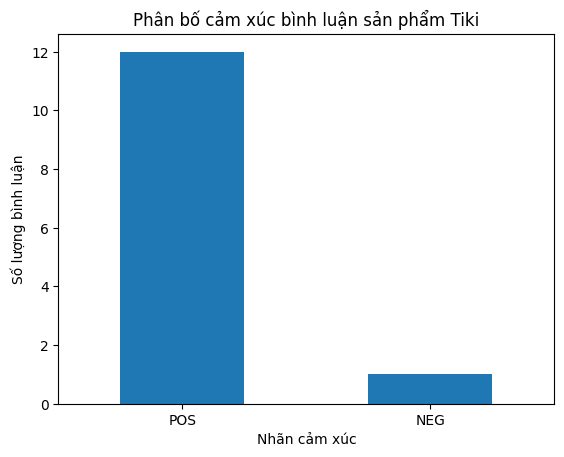


===== KẾT LUẬN TỰ ĐỘNG =====
Tổng số bình luận phân tích: 13
Tích cực: 12 bình luận (92.31%)
Trung tính: 0 bình luận (0.00%)
Tiêu cực: 1 bình luận (7.69%)
Kết luận: Sản phẩm có xu hướng được đánh giá tích cực. Phần lớn khách hàng hài lòng với sản phẩm.


In [22]:
# ============================================================
# CELL 20 - Crawler Tiki: lấy bình luận từ link sản phẩm
# ============================================================

import re
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt


def extract_tiki_ids(product_url):
    """
    Tách product_id và spid từ link sản phẩm Tiki.
    Ví dụ:
    https://tiki.vn/ten-san-pham-p278398007.html?...&spid=278398008#

    Kết quả:
    product_id = 278398007
    spid = 278398008
    """

    product_id = None
    spid = None

    product_match = re.search(r"-p(\d+)\.html", product_url)
    if product_match:
        product_id = product_match.group(1)

    spid_match = re.search(r"[?&]spid=(\d+)", product_url)
    if spid_match:
        spid = spid_match.group(1)

    if spid is None:
        spid = product_id

    if product_id is None:
        raise ValueError("Không tìm thấy product_id. Link Tiki phải có dạng ...-p123456.html")

    return product_id, spid


def crawl_tiki_reviews(product_url, max_pages=5, limit=20, sleep_time=0.5):
    """
    Lấy bình luận từ link sản phẩm Tiki.
    Trả về DataFrame gồm:
    comment, rating, title, created_at, product_id, spid
    """

    product_id, spid = extract_tiki_ids(product_url)

    print("product_id:", product_id)
    print("spid:", spid)

    api_url = "https://tiki.vn/api/v2/reviews"

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "Accept": "application/json, text/plain, */*",
        "Referer": product_url,
        "Origin": "https://tiki.vn",
    }

    all_reviews = []

    for page in range(1, max_pages + 1):
        params = {
            "limit": limit,
            "include": "comments,contribute_info,attribute_vote_summary",
            "sort": "score|desc,id|desc,stars|all",
            "page": page,
            "spid": spid,
            "product_id": product_id,
        }

        try:
            response = requests.get(
                api_url,
                headers=headers,
                params=params,
                timeout=15
            )

            if response.status_code != 200:
                print(f"Lỗi request trang {page}: status code = {response.status_code}")
                print(response.text[:500])
                break

            data = response.json()
            reviews = data.get("data", [])

            if len(reviews) == 0:
                print(f"Không còn bình luận ở trang {page}.")
                break

            for item in reviews:
                comment = item.get("content", "")
                title = item.get("title", "")
                rating = item.get("rating", None)
                created_at = item.get("created_at", "")

                comment = str(comment).strip() if comment is not None else ""
                title = str(title).strip() if title is not None else ""

                # Một số review có title nhưng content rỗng
                final_comment = comment
                if final_comment == "" and title != "":
                    final_comment = title

                if final_comment != "":
                    all_reviews.append({
                        "comment": final_comment,
                        "rating": rating,
                        "title": title,
                        "created_at": created_at,
                        "product_id": product_id,
                        "spid": spid
                    })

            print(f"Đã lấy trang {page}: {len(reviews)} bình luận")

            time.sleep(sleep_time)

        except Exception as e:
            print(f"Lỗi ở trang {page}: {e}")
            break

    df_reviews = pd.DataFrame(all_reviews)

    if df_reviews.empty:
        print("Không lấy được bình luận nào.")
        print("Nguyên nhân có thể là sản phẩm chưa có review, Tiki chặn request hoặc API thay đổi.")
    else:
        print(f"Tổng số bình luận lấy được: {len(df_reviews)}")

    return df_reviews


def analyze_tiki_reviews(df_reviews):
    """
    Phân tích bình luận Tiki bằng hàm predict_comment() đã có trong notebook.
    Nếu predict_comment chưa tồn tại hoặc chưa return dictionary, hàm sẽ báo rõ.
    """

    if df_reviews.empty:
        print("Không có bình luận để phân tích.")
        return pd.DataFrame()

    if "predict_comment" not in globals():
        print("Chưa tìm thấy hàm predict_comment().")
        print("Bạn hãy chạy các cell huấn luyện và cell định nghĩa predict_comment trước.")
        return pd.DataFrame()

    results = []

    for cmt in df_reviews["comment"]:
        pred = predict_comment(cmt)

        if isinstance(pred, dict):
            row = pred.copy()

            if "comment" not in row:
                row["comment"] = cmt

            results.append(row)

        else:
            results.append({
                "comment": cmt,
                "prediction": pred
            })

    df_predict = pd.DataFrame(results)

    print("Đã phân tích xong bình luận Tiki.")
    return df_predict


def summarize_tiki_analysis(df_predict):
    """
    Thống kê kết quả phân tích cảm xúc.
    Tự nhận diện cột nhãn nếu có tên predicted_label / label / prediction.
    """

    if df_predict.empty:
        print("Không có dữ liệu dự đoán để thống kê.")
        return

    label_col = None

    for col in ["predicted_label", "label", "prediction", "sentiment"]:
        if col in df_predict.columns:
            label_col = col
            break

    if label_col is None:
        print("Không tìm thấy cột nhãn cảm xúc trong df_predict.")
        print("Các cột hiện có:", df_predict.columns.tolist())
        return

    print("\n===== THỐNG KÊ CẢM XÚC =====")

    sentiment_count = df_predict[label_col].value_counts()
    sentiment_percent = df_predict[label_col].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        "Số lượng": sentiment_count,
        "Tỷ lệ (%)": sentiment_percent.round(2)
    })

    display(summary_df)

    # Vẽ biểu đồ
    sentiment_count.plot(kind="bar")
    plt.title("Phân bố cảm xúc bình luận sản phẩm Tiki")
    plt.xlabel("Nhãn cảm xúc")
    plt.ylabel("Số lượng bình luận")
    plt.xticks(rotation=0)
    plt.show()

    total = len(df_predict)
    pos = sentiment_count.get("POS", 0)
    neu = sentiment_count.get("NEU", 0)
    neg = sentiment_count.get("NEG", 0)

    pos_rate = pos / total * 100
    neu_rate = neu / total * 100
    neg_rate = neg / total * 100

    print("\n===== KẾT LUẬN TỰ ĐỘNG =====")
    print(f"Tổng số bình luận phân tích: {total}")
    print(f"Tích cực: {pos} bình luận ({pos_rate:.2f}%)")
    print(f"Trung tính: {neu} bình luận ({neu_rate:.2f}%)")
    print(f"Tiêu cực: {neg} bình luận ({neg_rate:.2f}%)")

    if pos_rate >= 60:
        conclusion = "Sản phẩm có xu hướng được đánh giá tích cực. Phần lớn khách hàng hài lòng với sản phẩm."
    elif neg_rate >= 40:
        conclusion = "Sản phẩm có khá nhiều phản hồi tiêu cực. Người mua nên xem kỹ các bình luận trước khi quyết định."
    else:
        conclusion = "Sản phẩm có đánh giá ở mức trung bình, phản hồi của khách hàng khá đa chiều."

    print("Kết luận:", conclusion)


# ============================================================
# CHẠY THỬ VỚI LINK TIKI CỦA BẠN
# ============================================================

tiki_url = "https://tiki.vn/sach-song-doi-rung-rinh-thong-dong-quan-xuyen-chuyen-tien-nong-huong-ve-an-tam-tai-chinh-p278398007.html?itm_campaign=CTP_YPD_TKA_PLA_UNK_ALL_UNK_UNK_UNK_UNK_X.312402_Y.1894722_Z.4057469_CN.Tu-dong---F4P&itm_medium=CPC&itm_source=tiki-ads&spid=278398008#"

# 1. Crawl bình luận
df_tiki_reviews = crawl_tiki_reviews(
    product_url=tiki_url,
    max_pages=5,
    limit=20,
    sleep_time=0.5
)

display(df_tiki_reviews.head())

# 2. Lưu dữ liệu crawl được
if not df_tiki_reviews.empty:
    df_tiki_reviews.to_csv(
        "tiki_reviews_crawled.csv",
        index=False,
        encoding="utf-8-sig"
    )
    print("Đã lưu file: tiki_reviews_crawled.csv")

# 3. Phân tích cảm xúc bằng model đã huấn luyện
df_tiki_predict = analyze_tiki_reviews(df_tiki_reviews)

display(df_tiki_predict.head())

# 4. Thống kê kết quả
summarize_tiki_analysis(df_tiki_predict)

## 21. Phân tích review Tiki sau khi crawl

In [23]:
# ============================================================
# CELL 21 - Kiểm tra kết quả crawl và phân tích Tiki
# ============================================================

import pandas as pd

print("===== KIỂM TRA DỮ LIỆU CRAWL TIKI =====")

# 1. Kiểm tra df_tiki_reviews
if "df_tiki_reviews" not in globals():
    print("Chưa có df_tiki_reviews. Bạn cần chạy Cell 20 trước.")
else:
    print("Số bình luận crawl được:", len(df_tiki_reviews))
    print("Các cột trong df_tiki_reviews:", df_tiki_reviews.columns.tolist())

    if not df_tiki_reviews.empty:
        display(df_tiki_reviews.head(10))

        print("\nPhân bố rating thật từ Tiki:")
        if "rating" in df_tiki_reviews.columns:
            display(df_tiki_reviews["rating"].value_counts().sort_index())
        else:
            print("Không có cột rating.")

print("\n===== KIỂM TRA KẾT QUẢ DỰ ĐOÁN =====")

# 2. Kiểm tra df_tiki_predict
if "df_tiki_predict" not in globals():
    print("Chưa có df_tiki_predict. Bạn cần chạy Cell 20 trước.")
else:
    print("Số bình luận đã dự đoán:", len(df_tiki_predict))
    print("Các cột trong df_tiki_predict:", df_tiki_predict.columns.tolist())

    if not df_tiki_predict.empty:
        display(df_tiki_predict.head(10))

        # Tự tìm cột nhãn cảm xúc
        label_col = None
        for col in ["predicted_label", "label", "prediction", "sentiment"]:
            if col in df_tiki_predict.columns:
                label_col = col
                break

        if label_col is not None:
            print(f"\nPhân bố cảm xúc dự đoán theo cột '{label_col}':")
            display(df_tiki_predict[label_col].value_counts())

            print("\nTỷ lệ cảm xúc (%):")
            display((df_tiki_predict[label_col].value_counts(normalize=True) * 100).round(2))
        else:
            print("Không tìm thấy cột nhãn cảm xúc trong df_tiki_predict.")

        # Tự tìm cột rating dự đoán
        rating_col = None
        for col in ["predicted_rating", "rating_pred", "pred_rating"]:
            if col in df_tiki_predict.columns:
                rating_col = col
                break

        if rating_col is not None:
            print(f"\nPhân bố rating dự đoán theo cột '{rating_col}':")
            display(df_tiki_predict[rating_col].value_counts().sort_index())
        else:
            print("Không tìm thấy cột rating dự đoán trong df_tiki_predict.")

print("\n===== GỢI Ý DÙNG CHO BÁO CÁO =====")

if "df_tiki_reviews" in globals() and "df_tiki_predict" in globals():
    if not df_tiki_reviews.empty and not df_tiki_predict.empty:
        print("""
Bạn có thể chụp màn hình các phần sau để đưa vào báo cáo:
1. Bảng bình luận crawl được từ Tiki.
2. Bảng kết quả dự đoán cảm xúc.
3. Phân bố rating thật từ Tiki.
4. Phân bố cảm xúc dự đoán POS / NEU / NEG.
5. Kết luận tự động ở Cell 20.
""")
    else:
        print("""
Cell 20 đã chạy nhưng chưa có đủ dữ liệu.
Nếu df_tiki_reviews rỗng, nguyên nhân có thể là:
1. Sản phẩm chưa có bình luận.
2. Tiki chặn request.
3. API Tiki thay đổi.
4. Link sản phẩm không có review công khai.

Khi bảo vệ, nên chuẩn bị thêm file CSV đã crawl sẵn để demo dự phòng.
""")

===== KIỂM TRA DỮ LIỆU CRAWL TIKI =====
Số bình luận crawl được: 13
Các cột trong df_tiki_reviews: ['comment', 'rating', 'title', 'created_at', 'product_id', 'spid']


,comment,rating,title,created_at,product_id,spid
0,Tốt có HN nkfgn BV xD rồi đi buoond đ VN nk,5,Cực kì hài lòng,1774955521,278398007,278398008
1,"Quyển này viết về tài chính mà đọc khá chill, tác giả viết cũng khá dễ hiểu, sách ứng dụng nhiều model tài chính đơn...",5,Cực kì hài lòng,1754295222,278398007,278398008
2,Sách ngoài thì đẹp nội dung rất hay quá xứng đáng,5,Cực kì hài lòng,1754293332,278398007,278398008
3,"Sách ok mà gửi email spam quá chừng, huỷ rồi vẫn spam",1,Rất không hài lòng,1775746249,278398007,278398008
4,Cực kì hài lòng,5,Cực kì hài lòng,1775429688,278398007,278398008
5,Cực kì hài lòng,5,Cực kì hài lòng,1766296004,278398007,278398008
6,Cực kì hài lòng,5,Cực kì hài lòng,1765609696,278398007,278398008
7,Cực kì hài lòng,5,Cực kì hài lòng,1764638048,278398007,278398008
8,Cực kì hài lòng,5,Cực kì hài lòng,1764476162,278398007,278398008
9,Cực kì hài lòng,5,Cực kì hài lòng,1760792177,278398007,278398008



Phân bố rating thật từ Tiki:


rating
1     1
5    12
Name: count, dtype: int64


===== KIỂM TRA KẾT QUẢ DỰ ĐOÁN =====
Số bình luận đã dự đoán: 13
Các cột trong df_tiki_predict: ['original_text', 'clean_text', 'label', 'label_name', 'rating', 'rating_name', 'confidence_margin', 'comment']


...


Phân bố cảm xúc dự đoán theo cột 'label':


label
POS    12
NEG     1
Name: count, dtype: int64


Tỷ lệ cảm xúc (%):


label
POS    92.31
NEG     7.69
Name: proportion, dtype: float64

Không tìm thấy cột rating dự đoán trong df_tiki_predict.

===== GỢI Ý DÙNG CHO BÁO CÁO =====

Bạn có thể chụp màn hình các phần sau để đưa vào báo cáo:
1. Bảng bình luận crawl được từ Tiki.
2. Bảng kết quả dự đoán cảm xúc.
3. Phân bố rating thật từ Tiki.
4. Phân bố cảm xúc dự đoán POS / NEU / NEG.
5. Kết luận tự động ở Cell 20.



## 22. Kết luận trong notebook

Sau khi chạy xong notebook này, bạn có:

1. Dataset đã được kiểm tra và làm sạch tốt hơn.
2. Model phân loại cảm xúc `POS / NEU / NEG`.
3. Model dự đoán rating `1-5 sao`.
4. Hàm chatbot trả lời tự động.
5. Hàm phân tích nhiều bình luận.
6. Hàm crawl review từ link Tiki.
7. File model đã lưu trong `artifacts/` để triển khai app.

Bước tiếp theo nên làm:

- Tạo app Streamlit hoặc Flask để nhập bình luận/link Tiki.
- Khi người dùng nhập bình luận: gọi `app_predict()` + `generate_reply()`.
- Khi người dùng nhập link Tiki: gọi `crawl_tiki_reviews()` + `analyze_tiki_product_reviews()`.
- Đưa biểu đồ, bảng thống kê và bình luận tiêu biểu lên giao diện.